In [ ]:
print("done")

In [1]:
%cd ..

C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics


In [2]:
import os

os.getcwd()

'C:\\Beryllium Base\\WORKSPACES\\MTECH\\dl-gen-lyrics'

In [3]:
# Allowing dynamic links, hot-reload, to our custom modules
%load_ext autoreload
%autoreload 2

In [4]:
from aspect_turquoise import Turquoise

In [5]:
from generator_core.impl.Vocabulary import SimpleVocabulary

In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [7]:
from generator_core import Trainer

In [8]:
solution = Turquoise()

In [9]:
streamer = solution.load_dataset()

In [10]:
next(streamer.stream())

["Ahe's My Kind Of Girl",
 'ABBA',
 "Look at her face, it's a wonderful face  \nAnd it means something special to me  \nLook at the way that she smiles when she sees me  \nHow lucky can one fellow be?  \n  \nShe's just my kind of girl, she makes me feel fine  \nWho could ever believe that she could be mine?  \nShe's just my kind of girl, without her I'm blue  \nAnd if she ever leaves me what could I do, what could I do?  \n  \nAnd when we go for a walk in the park  \nAnd she holds me and squeezes my hand  \nWe'll go on walking for hours and talking  \nAbout all the things that we plan  \n  \nShe's just my kind of girl, she makes me feel fine  \nWho could ever believe that she could be mine?  \nShe's just my kind of girl, without her I'm blue  \nAnd if she ever leaves me what could I do, what could I do?\n\n",
 'null']

In [11]:
small_dataset = []
for line in streamer.stream():
    small_dataset.append(line)
    if len(small_dataset) > 10000:
        break

In [12]:
_, _, content, _ = small_dataset[0]
content

"Look at her face, it's a wonderful face  \nAnd it means something special to me  \nLook at the way that she smiles when she sees me  \nHow lucky can one fellow be?  \n  \nShe's just my kind of girl, she makes me feel fine  \nWho could ever believe that she could be mine?  \nShe's just my kind of girl, without her I'm blue  \nAnd if she ever leaves me what could I do, what could I do?  \n  \nAnd when we go for a walk in the park  \nAnd she holds me and squeezes my hand  \nWe'll go on walking for hours and talking  \nAbout all the things that we plan  \n  \nShe's just my kind of girl, she makes me feel fine  \nWho could ever believe that she could be mine?  \nShe's just my kind of girl, without her I'm blue  \nAnd if she ever leaves me what could I do, what could I do?\n\n"

In [13]:
content = solution.clean_text(content)
content

"look at her face , it's a wonderful face \n and it means something special to me \n look at the way that she smiles when she sees me \n how lucky can one fellow be ? \n \n she's just my kind of girl , she makes me feel fine \n who could ever believe that she could be mine ? \n she's just my kind of girl , without her i'm blue \n and if she ever leaves me what could i do , what could i do ? \n \n and when we go for a walk in the park \n and she holds me and squeezes my hand \n we'll go on walking for hours and talking \n about all the things that we plan \n \n she's just my kind of girl , she makes me feel fine \n who could ever believe that she could be mine ? \n she's just my kind of girl , without her i'm blue \n and if she ever leaves me what could i do , what could i do ?"

In [14]:
annotation = solution.annotate_text(content)
annotation

In [15]:
literal_tokens = solution.tokenize_text(content)
print(literal_tokens)

['<SONG_START>', 'look', 'at', 'her', 'face', ',', "it's", 'a', 'wonderful', 'face', '<LINE>', 'and', 'it', 'means', 'something', 'special', 'to', 'me', '<LINE>', 'look', 'at', 'the', 'way', 'that', 'she', 'smiles', 'when', 'she', 'sees', 'me', '<LINE>', 'how', 'lucky', 'can', 'one', 'fellow', 'be', '?', '<LINE>', '<LINE>', "she's", 'just', 'my', 'kind', 'of', 'girl', ',', 'she', 'makes', 'me', 'feel', 'fine', '<LINE>', 'who', 'could', 'ever', 'believe', 'that', 'she', 'could', 'be', 'mine', '?', '<LINE>', "she's", 'just', 'my', 'kind', 'of', 'girl', ',', 'without', 'her', "i'm", 'blue', '<LINE>', 'and', 'if', 'she', 'ever', 'leaves', 'me', 'what', 'could', 'i', 'do', ',', 'what', 'could', 'i', 'do', '?', '<LINE>', '<LINE>', 'and', 'when', 'we', 'go', 'for', 'a', 'walk', 'in', 'the', 'park', '<LINE>', 'and', 'she', 'holds', 'me', 'and', 'squeezes', 'my', 'hand', '<LINE>', "we'll", 'go', 'on', 'walking', 'for', 'hours', 'and', 'talking', '<LINE>', 'about', 'all', 'the', 'things', 'that'

In [16]:
solution.vocabulary = SimpleVocabulary({"<SONG_START>", "<SONG_END>", "<LINE>", "<STANZA>"})
for token in literal_tokens:
    vocabulary = solution.build_vocabulary(token)
len(vocabulary)

45

In [17]:
print(solution.vocabulary.word2idx)

{'<PAD>': 0, '<UNKNOWN>': 1, '<SONG_START>': 2, '<SONG_END>': 3, '<LINE>': 4, '<STANZA>': 5, 'face': 6, 'look': 7, 'at': 8, 'she': 9, 'me': 10, ',': 11, 'that': 12, 'could': 13, 'be': 14, '?': 15, "she's": 16, 'just': 17, 'my': 18, 'kind': 19, 'of': 20, 'girl': 21, 'her': 22, 'and': 23, 'ever': 24, 'what': 25, 'i': 26, 'do': 27, 'when': 28, 'a': 29, 'the': 30, 'go': 31, 'for': 32, 'we': 33, 'makes': 34, 'feel': 35, 'fine': 36, 'who': 37, 'believe': 38, 'mine': 39, 'without': 40, "i'm": 41, 'blue': 42, 'if': 43, 'leaves': 44}


In [18]:
indicial_tokens = np.zeros(len(literal_tokens), dtype=np.long)
for i, token in enumerate(literal_tokens): indicial_tokens[i] = vocabulary.encode(token)
indicial_tokens

array([ 2,  7,  8, 22,  6, 11,  1, 29,  1,  6,  4, 23,  1,  1,  1,  1,  1,
       10,  4,  7,  8, 30,  1, 12,  9,  1, 28,  9,  1, 10,  4,  1,  1,  1,
        1,  1, 14, 15,  4,  4, 16, 17, 18, 19, 20, 21, 11,  9, 34, 10, 35,
       36,  4, 37, 13, 24, 38, 12,  9, 13, 14, 39, 15,  4, 16, 17, 18, 19,
       20, 21, 11, 40, 22, 41, 42,  4, 23, 43,  9, 24, 44, 10, 25, 13, 26,
       27, 11, 25, 13, 26, 27, 15,  4,  4, 23, 28, 33, 31, 32, 29,  1,  1,
       30,  1,  4, 23,  9,  1, 10, 23,  1, 18,  1,  4,  1, 31,  1,  1, 32,
        1, 23,  1,  4,  1,  1, 30,  1, 12, 33,  1,  4,  4, 16, 17, 18, 19,
       20, 21, 11,  9, 34, 10, 35, 36,  4, 37, 13, 24, 38, 12,  9, 13, 14,
       39, 15,  4, 16, 17, 18, 19, 20, 21, 11, 40, 22, 41, 42,  4, 23, 43,
        9, 24, 44, 10, 25, 13, 26, 27, 11, 25, 13, 26, 27, 15,  3],
      dtype=int32)

In [19]:
indicial_tokens.max()

np.int32(44)

In [20]:
solution.prepare_embedder(None)

In [21]:
embeds = solution.embed_tokens(indicial_tokens)
embeds

array([ 2,  7,  8, 22,  6, 11,  1, 29,  1,  6,  4, 23,  1,  1,  1,  1,  1,
       10,  4,  7,  8, 30,  1, 12,  9,  1, 28,  9,  1, 10,  4,  1,  1,  1,
        1,  1, 14, 15,  4,  4, 16, 17, 18, 19, 20, 21, 11,  9, 34, 10, 35,
       36,  4, 37, 13, 24, 38, 12,  9, 13, 14, 39, 15,  4, 16, 17, 18, 19,
       20, 21, 11, 40, 22, 41, 42,  4, 23, 43,  9, 24, 44, 10, 25, 13, 26,
       27, 11, 25, 13, 26, 27, 15,  4,  4, 23, 28, 33, 31, 32, 29,  1,  1,
       30,  1,  4, 23,  9,  1, 10, 23,  1, 18,  1,  4,  1, 31,  1,  1, 32,
        1, 23,  1,  4,  1,  1, 30,  1, 12, 33,  1,  4,  4, 16, 17, 18, 19,
       20, 21, 11,  9, 34, 10, 35, 36,  4, 37, 13, 24, 38, 12,  9, 13, 14,
       39, 15,  4, 16, 17, 18, 19, 20, 21, 11, 40, 22, 41, 42,  4, 23, 43,
        9, 24, 44, 10, 25, 13, 26, 27, 11, 25, 13, 26, 27, 15,  3],
      dtype=int32)

In [22]:
sample = solution.inject_sample(embeds, annotation)
sample

array([ 2,  7,  8, 22,  6, 11,  1, 29,  1,  6,  4, 23,  1,  1,  1,  1,  1,
       10,  4,  7,  8, 30,  1, 12,  9,  1, 28,  9,  1, 10,  4,  1,  1,  1,
        1,  1, 14, 15,  4,  4, 16, 17, 18, 19, 20, 21, 11,  9, 34, 10, 35,
       36,  4, 37, 13, 24, 38, 12,  9, 13, 14, 39, 15,  4, 16, 17, 18, 19,
       20, 21, 11, 40, 22, 41, 42,  4, 23, 43,  9, 24, 44, 10, 25, 13, 26,
       27, 11, 25, 13, 26, 27, 15,  4,  4, 23, 28, 33, 31, 32, 29,  1,  1,
       30,  1,  4, 23,  9,  1, 10, 23,  1, 18,  1,  4,  1, 31,  1,  1, 32,
        1, 23,  1,  4,  1,  1, 30,  1, 12, 33,  1,  4,  4, 16, 17, 18, 19,
       20, 21, 11,  9, 34, 10, 35, 36,  4, 37, 13, 24, 38, 12,  9, 13, 14,
       39, 15,  4, 16, 17, 18, 19, 20, 21, 11, 40, 22, 41, 42,  4, 23, 43,
        9, 24, 44, 10, 25, 13, 26, 27, 11, 25, 13, 26, 27, 15,  3],
      dtype=int32)

In [23]:
model = solution.prepare_model()
model

M2OLSTM(
  (embedding): Embedding(45, 200, padding_idx=0)
  (lstm): LSTM(200, 256, num_layers=2, batch_first=True, bidirectional=True)
  (linear): Linear(in_features=512, out_features=45, bias=True)
)

In [24]:
print("Hmm")
_input = sample[None, :20].astype(np.long)
preds = model.forward(torch.tensor(_input), torch.tensor([len(x) for x in _input]))
print("Hmm")

Hmm
Hmm


In [25]:
preds.shape

torch.Size([1, 45])

In [26]:
from torch.utils.data import IterableDataset, DataLoader, dataloader
from torch.nn.utils.rnn import pad_sequence

In [27]:
solution.vocabulary = SimpleVocabulary({"<SONG_START>", "<SONG_END>", "<LINE>", "<STANZA>"})
for _, _, content, _ in small_dataset:
    content = solution.clean_text(content)
    annotation = solution.annotate_text(content)
    literal_tokens = solution.tokenize_text(content)
    for token in literal_tokens:
        vocabulary = solution.build_vocabulary(token)

In [28]:
len(vocabulary)

20916

In [29]:
total, corrects = 0, 0
micros = []
for _, _, content, _ in small_dataset:
    content = solution.clean_text(content)
    annotation = solution.annotate_text(content)
    literal_tokens = solution.tokenize_text(content)
    indicial_tokens = map(vocabulary.encode, literal_tokens)
    reconstructed_literals = map(vocabulary.decode, indicial_tokens)
    retained_literals = len(literal_tokens) - len([x for x in reconstructed_literals if x == '<UNKNOWN>'])
    total += len(literal_tokens)
    corrects += retained_literals
    micros.append(retained_literals / len(literal_tokens))
print("Acc1", corrects / total)
print("Acc2", np.mean(micros))

Acc1 0.994270098342264
Acc2 0.9944515660656208


In [30]:
for _, _, content, _ in small_dataset[:2]:
    content = solution.clean_text(content)
    annotation = solution.annotate_text(content)
    literal_tokens = solution.tokenize_text(content)
    indicial_tokens = map(vocabulary.encode, literal_tokens)
    reconstructed_literals = map(vocabulary.decode, indicial_tokens)
    print(" ".join(reconstructed_literals))
    print()

<SONG_START> look at her face , it's a wonderful face <LINE> and it means something special to me <LINE> look at the way that she smiles when she sees me <LINE> how lucky can one fellow be ? <LINE> <LINE> she's just my kind of girl , she makes me feel fine <LINE> who could ever believe that she could be mine ? <LINE> she's just my kind of girl , without her i'm blue <LINE> and if she ever leaves me what could i do , what could i do ? <LINE> <LINE> and when we go for a walk in the park <LINE> and she holds me and <UNKNOWN> my hand <LINE> we'll go on walking for hours and talking <LINE> about all the things that we plan <LINE> <LINE> she's just my kind of girl , she makes me feel fine <LINE> who could ever believe that she could be mine ? <LINE> she's just my kind of girl , without her i'm blue <LINE> and if she ever leaves me what could i do , what could i do ? <SONG_END>

<SONG_START> take it easy with me , please <LINE> touch me gently like a summer evening breeze <LINE> take your tim

In [31]:
def collate_fn(batch, pad_idx=0):
    xs, ys = list(zip(*batch))
    # print('xs', xs[0].shape, 'ys', ys[0], xs[0][-1])
    lengths = torch.tensor([len(x) for x in xs])
    xs = pad_sequence(xs, batch_first=True, padding_value=pad_idx)
    # ys = pad_sequence(ys, batch_first=True, padding_value=pad_idx)
    ys = torch.stack(ys)
    # print("xs, ys", xs.shape, ys.shape)  # torch.Size([2, 633]) torch.Size([2, 633])
    return xs, lengths, ys

In [ ]:
model = solution.prepare_model()

In [72]:
class MyDataset(IterableDataset):
    def __iter__(self):
        what = 0
        for _, _, content, _ in small_dataset[:10]:
            content = solution.clean_text(content)
            annotation = solution.annotate_text(content)
            literal_tokens = solution.tokenize_text(content)
            if len(literal_tokens) < 2:  continue
            indicial_tokens = np.zeros(len(literal_tokens), dtype=np.long)
            for i, token in enumerate(literal_tokens): indicial_tokens[i] = vocabulary.encode(token)
            embeds = solution.embed_tokens(indicial_tokens)
            sample = solution.inject_sample(embeds, annotation)
            sample = torch.tensor(sample.astype(np.long))
            # print("sample[:-1], sample[1:]", sample[:-1].shape, sample[1:].shape)  # sample[1:] torch.Size([178]) torch.Size([178])
            # for i in range(1 + (what % 4), len(sample), 4):
            for i in range(1, len(sample)):
                yield sample[:i], sample[i].type(torch.long)
            # what = (what + 1) % 4


dataset = MyDataset()
loader = DataLoader(
    dataset,
    batch_size=64,
    collate_fn=collate_fn,
)

In [57]:
i = 0
for data in loader:
    i += 1
    print(data[0].shape, data[1], data[2])
    if i == 1: break

torch.Size([64, 64]) tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
        37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54,
        55, 56, 57, 58, 59, 60, 61, 62, 63, 64]) tensor([   7,    8,   22,    6,   11,   93,   29, 1205,    6,    4,   23,   45,
         340,  278,  687,   81,   10,    4,    7,    8,   30,   89,   12,    9,
        1073,   28,    9,  192,   10,    4,   52, 1276,  126,  183, 1112,   14,
          15,    4,    4,   16,   17,   18,   19,   20,   21,   11,    9,   34,
          10,   35,   36,    4,   37,   13,   24,   38,   12,    9,   13,   14,
          39,   15,    4,   16])


In [114]:
trainer = Trainer(
    model=model,
    train_dataloader=loader,
    epochs=1,
    optimizer=lambda params: torch.optim.Adam(params, lr=0.003),
    # model_train_step=lambda model, x, y: model(x, y).permute(0, 2, 1), # [batch, seq, vocab] to [batch, vocab, seq]
    model_train_step=lambda model, data: model(data[0], data[1]),
    device="cuda",
)

In [115]:
# CPU 12 min, GPU 7-12 min
print("Poof")
trainer.train()
print("Poof")

Poof
Epoch: 1/10, Train Loss=0.98507, Val Loss=-1.00000
Epoch: 2/10, Train Loss=0.48925, Val Loss=-1.00000
Epoch: 3/10, Train Loss=0.22774, Val Loss=-1.00000
Epoch: 4/10, Train Loss=0.16855, Val Loss=-1.00000
Epoch: 5/10, Train Loss=0.14715, Val Loss=-1.00000
Epoch: 6/10, Train Loss=0.12109, Val Loss=-1.00000
Epoch: 7/10, Train Loss=0.10543, Val Loss=-1.00000
Epoch: 8/10, Train Loss=0.08736, Val Loss=-1.00000
Epoch: 9/10, Train Loss=0.07428, Val Loss=-1.00000
Epoch: 10/10, Train Loss=0.06974, Val Loss=-1.00000
Poof


In [44]:
trainer.loss

{'train': [np.float64(5.33830122873286), np.float64(3.4867418213174797)],
 'val': []}

In [116]:
with torch.no_grad():
    for x, l, y in loader: break
    x, l, y = x[:1], l[:1], y[:1]
    p = model.forward(x.to(trainer.device), l.to(trainer.device)).to('cpu')
    print(vocabulary.decode(preds.argmax().item()), end=' ')

at 

In [117]:
with torch.no_grad():
    for x, l, y in loader: break
    x, l, y = x[48:49], l[48:49], y[48:49]
    embedded = model.embedding(_input.to(trainer.device))
    outputs, _ = model.lstm(embedded)

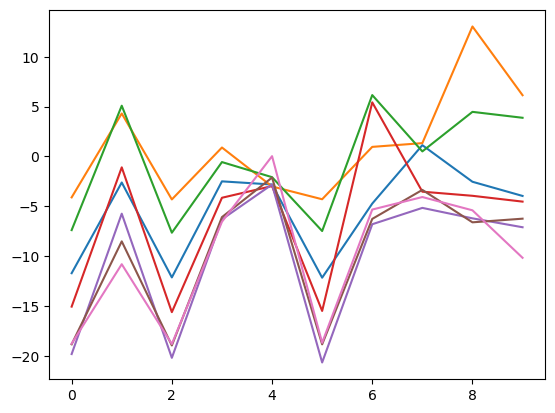

In [118]:
with torch.no_grad():
    plt.plot(model.linear(outputs[:, 0, :]).detach().to('cpu').numpy()[0, :10])
    plt.plot(model.linear(outputs[:, 1, :]).detach().to('cpu').numpy()[0, :10])
    plt.plot(model.linear(outputs[:, 2, :]).detach().to('cpu').numpy()[0, :10])
    plt.plot(model.linear(outputs[:, 3, :]).detach().to('cpu').numpy()[0, :10])
    plt.plot(model.linear(outputs[:, 4, :]).detach().to('cpu').numpy()[0, :10])
    plt.plot(model.linear(outputs[:, 5, :]).detach().to('cpu').numpy()[0, :10])
    plt.plot(model.linear(outputs[:, 6, :]).detach().to('cpu').numpy()[0, :10])
    plt.show()

In [120]:
for _, _, content, _ in small_dataset[:1]:
    content = solution.clean_text(content)
    annotation = solution.annotate_text(content)
    literal_tokens = solution.tokenize_text(content)
    indicial_tokens = np.zeros(len(literal_tokens), dtype=np.long)
    for i, token in enumerate(literal_tokens): indicial_tokens[i] = vocabulary.encode(token)
    embeds = solution.embed_tokens(indicial_tokens)
    sample = solution.inject_sample(embeds, annotation)
    sample = torch.tensor(sample.astype(np.long))
    # yield sample[:-1], sample[-1].type(torch.long)
    for i in range(3, min(20, len(sample))):
        _input = sample[None, :i]
        with torch.no_grad():
            preds = model.forward(torch.tensor(_input).to(trainer.device), torch.tensor([len(x) for x in _input]).to(trainer.device)).to('cpu')
        thing = vocabulary.decode(preds.argmax().item())
        print(literal_tokens[:i], thing)

['<SONG_START>', 'look', 'at'] her
['<SONG_START>', 'look', 'at', 'her'] face
['<SONG_START>', 'look', 'at', 'her', 'face'] ,
['<SONG_START>', 'look', 'at', 'her', 'face', ','] it's
['<SONG_START>', 'look', 'at', 'her', 'face', ',', "it's"] a
['<SONG_START>', 'look', 'at', 'her', 'face', ',', "it's", 'a'] wonderful
['<SONG_START>', 'look', 'at', 'her', 'face', ',', "it's", 'a', 'wonderful'] face
['<SONG_START>', 'look', 'at', 'her', 'face', ',', "it's", 'a', 'wonderful', 'face'] <LINE>
['<SONG_START>', 'look', 'at', 'her', 'face', ',', "it's", 'a', 'wonderful', 'face', '<LINE>'] and
['<SONG_START>', 'look', 'at', 'her', 'face', ',', "it's", 'a', 'wonderful', 'face', '<LINE>', 'and'] it
['<SONG_START>', 'look', 'at', 'her', 'face', ',', "it's", 'a', 'wonderful', 'face', '<LINE>', 'and', 'it'] means
['<SONG_START>', 'look', 'at', 'her', 'face', ',', "it's", 'a', 'wonderful', 'face', '<LINE>', 'and', 'it', 'means'] something
['<SONG_START>', 'look', 'at', 'her', 'face', ',', "it's", 'a', 

C:\Users\mcxiv\AppData\Local\Temp\ipykernel_7908\4216509192.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  preds = model.forward(torch.tensor(_input).to(trainer.device), torch.tensor([len(x) for x in _input]).to(trainer.device)).to('cpu')


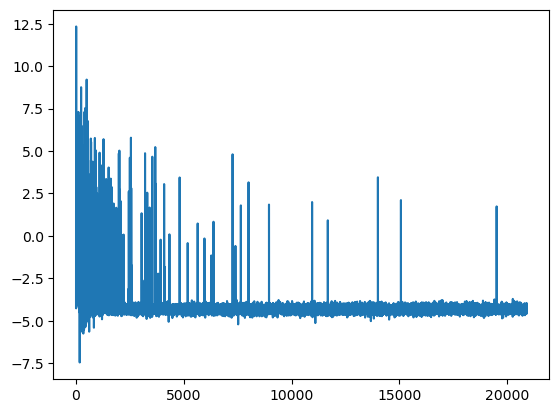

In [111]:
plt.plot(preds[0])
plt.show()

C:\Users\mcxiv\AppData\Local\Temp\ipykernel_7908\627644288.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  plt.plot(torch.nn.functional.softmax(preds[0]))


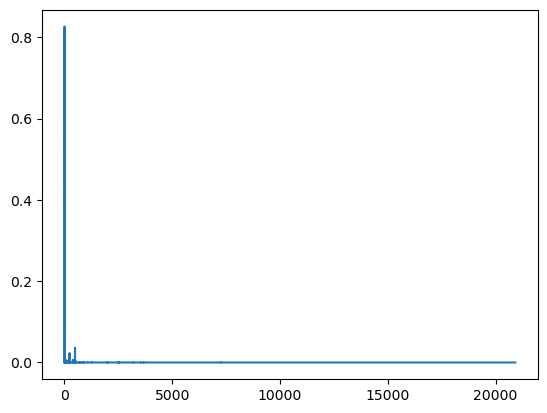

In [113]:
plt.plot(torch.nn.functional.softmax(preds[0]))
plt.show()

In [97]:
preds.shape

torch.Size([1, 20916])